In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\Python files\\data\\heart-disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape

(303, 14)

In [4]:
# data preparation
x = df.drop('target', axis= 1)
y = df['target']

x.shape, y.shape

((303, 13), (303,))

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.2, random_state =42)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [6]:
# model selection
from sklearn.ensemble import RandomForestClassifier #<<- loading the model
model= RandomForestClassifier() # <<- model selection

#viewing the model's parameters
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [18]:
#model training
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=95)

In [19]:
#checking the model's accuracy on the training data
from sklearn.metrics import accuracy_score
model.score(x_train, y_train)

1.0

In [20]:
# testing the model on the test data
y_preds= model.predict(x_test)
y_preds

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [21]:
#Evaluating the accuracy of the model on the test data
model.score(x_test,y_test)

0.8524590163934426

In [24]:
# Further model analysis
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [26]:
confusion_matrix(y_test, y_preds)

array([[24,  5],
       [ 4, 28]])

In [13]:
accuracy_score(y_test, y_preds) 

0.8688524590163934

### improve the model
Try different n_estimators to find the best

In [27]:
for i in range(10, 105, 5):
    print(f"Trying model with {i} estimatiors...")
    model = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"Model accuracy on test data: {model.score(x_test, y_test)* 100:.2f} %")
    print("")

Trying model with 10 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 15 estimatiors...
Model accuracy on test data: 83.61 %

Trying model with 20 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 25 estimatiors...
Model accuracy on test data: 81.97 %

Trying model with 30 estimatiors...
Model accuracy on test data: 81.97 %

Trying model with 35 estimatiors...
Model accuracy on test data: 86.89 %

Trying model with 40 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 45 estimatiors...
Model accuracy on test data: 81.97 %

Trying model with 50 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 55 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 60 estimatiors...
Model accuracy on test data: 85.25 %

Trying model with 65 estimatiors...
Model accuracy on test data: 83.61 %

Trying model with 70 estimatiors...
Model accuracy on test data: 86.89 %

Trying model with 75 estimatiors...
Mo

In [15]:
#from the above output, we have seen the best estimator is 95 at 88.52 % accuracy
#let's set the final estimatior to be 95 and not 100
model= RandomForestClassifier(n_estimators=95).fit(x_train, y_train)
model.score(x_test, y_test)
#note that it is almost impossible to get the previous accuracy score eventhough we
#have already set a random_state; this is because ensembe models are still random within themselves

0.819672131147541

#### saving and loading a model

In [16]:
#Saving the model
import pickle
pickle.dump(model, open("random_forest_model.pkl", "wb"))

In [17]:
#Loading the model
loaded_model= pickle.load(open("random_forest_model.pkl", "rb")) 
#loaded_model.score(x_test, y_test) #using the loaded model

In [1]:
from matplotlib import pyplot as plt
plt.hist(df)

NameError: name 'df' is not defined

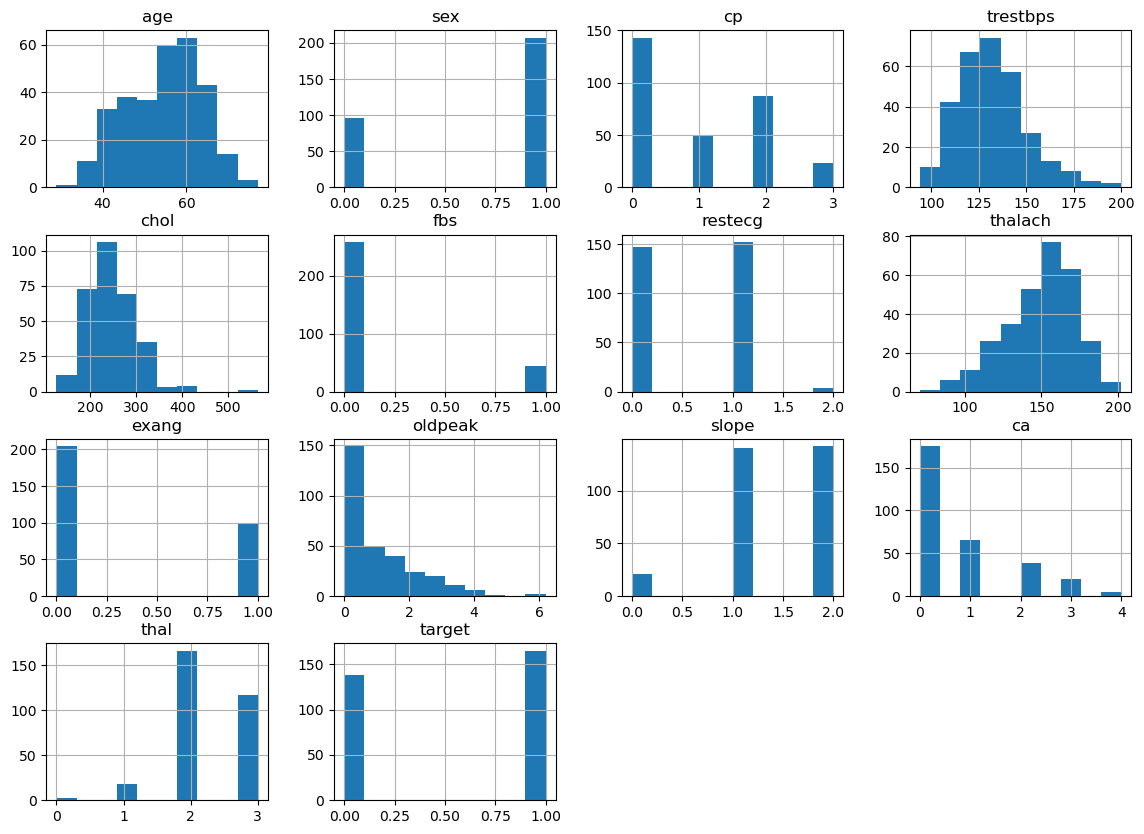

In [48]:
df.hist(figsize=(14,10))
plt.show()

In [52]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

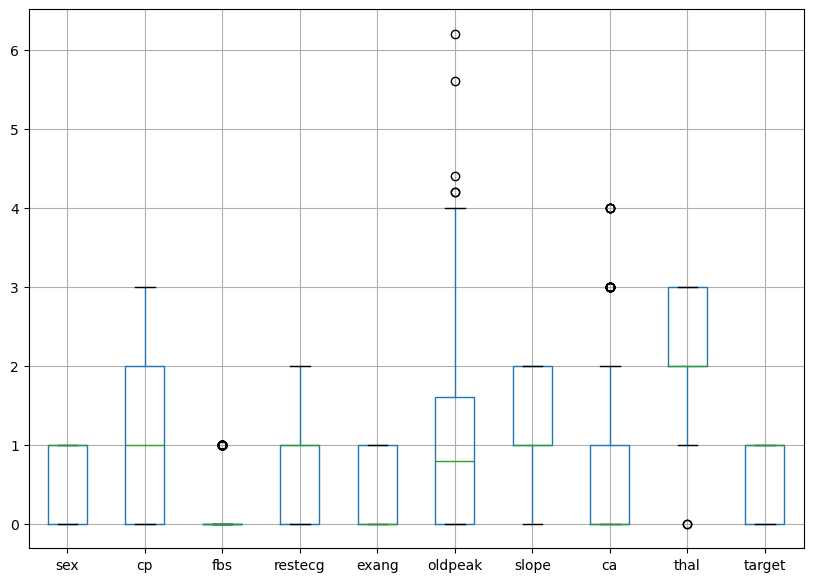

In [55]:
df[['sex', 'cp', 'fbs', 'restecg','exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']].boxplot(figsize=(10, 7))
plt.show()

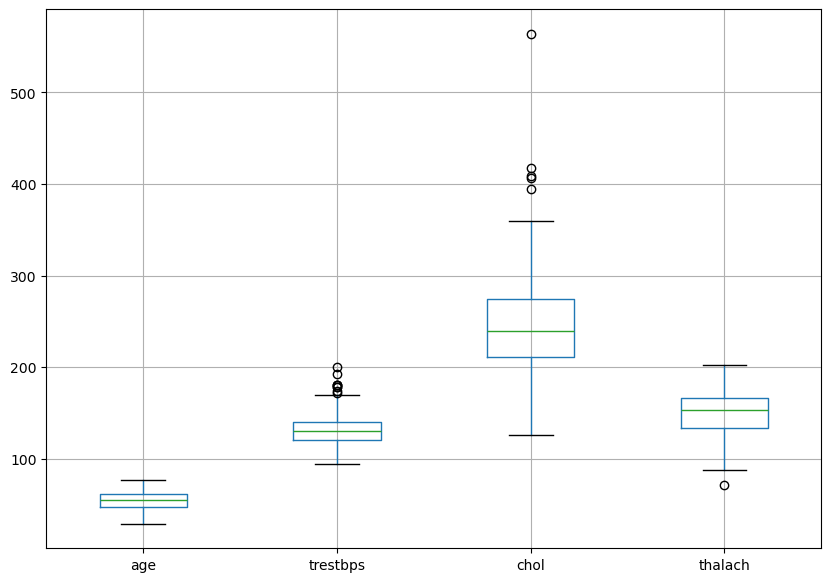

In [54]:
df[['age', 'trestbps', 'chol', 'thalach']].boxplot(figsize=(10, 7))
plt.show()

In [60]:
scatter_matrix(df)
plt.show()

NameError: name 'scatter_matrix' is not defined

In [61]:
scatter_matrix(df)
plt.show()

NameError: name 'scatter_matrix' is not defined